# Part 1 – Non-Linear Regression:

In [33]:
# Import libraries and set random seed

import numpy as np
import matplotlib.pyplot as plt

from sklearn.linear_model import Ridge, LinearRegression
from sklearn.preprocessing import PolynomialFeatures
from sklearn.metrics import mean_squared_error

# For reproducible results (so we get the same random numbers every time)
np.random.seed(42)

## A) Generating the dataset S
- We created 25 random x values in [0, 1]
- Then we computed y = sin(5πx) + noise, where noise is uniform in [-0.3, 0.3]

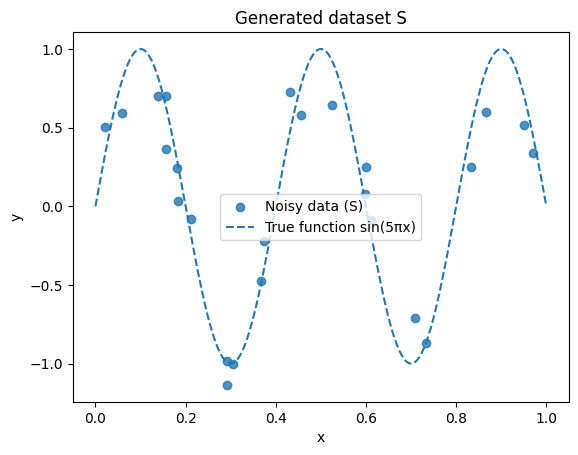

In [34]:
n_samples = 25

# x values: 25 random numbers between 0 and 1, shape (25, 1)
x = np.random.rand(n_samples, 1)

# noise: random values between -0.3 and 0.3
noise = np.random.uniform(-0.3, 0.3, size=(n_samples, 1))

# true clean function values: y = sin(5πx)
y_true_clean = np.sin(5 * np.pi * x)

# observed y with noise
y = y_true_clean + noise

# Plot the generated data and the true function
x_dense = np.linspace(0, 1, 200).reshape(-1, 1)
y_dense_true = np.sin(5 * np.pi * x_dense)

plt.figure()
plt.scatter(x, y, label="Noisy data (S)", alpha=0.8)
plt.plot(x_dense, y_dense_true, label="True function sin(5πx)", linestyle="--")
plt.xlabel("x")
plt.ylabel("y")
plt.title("Generated dataset S")
plt.legend()
plt.show()


### Fitting Ridge regression models with polynomial features
- We used degree 9 polynomial features and try these 5 λ values:
- λ ∈ {0, 1e-12, 1e-10, 1e-8, 0.01}

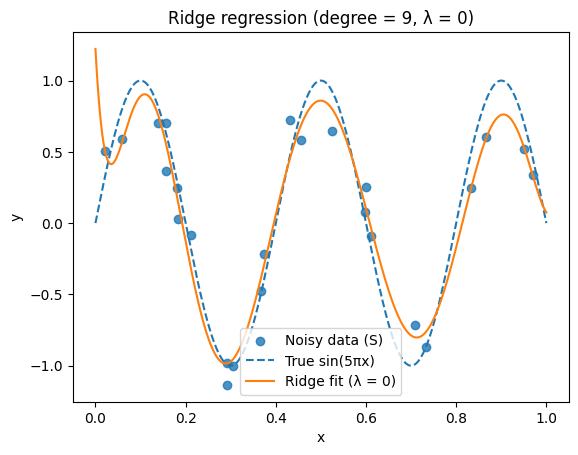

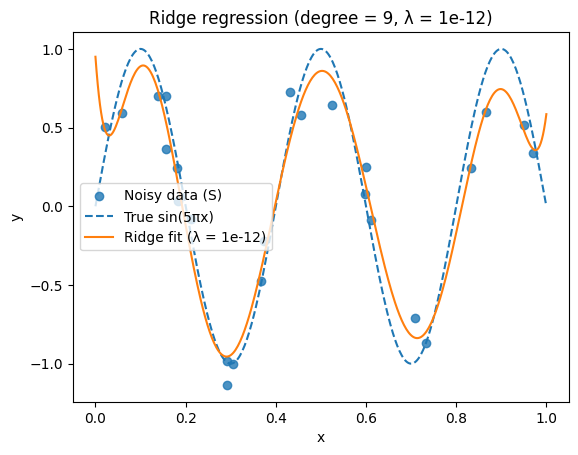

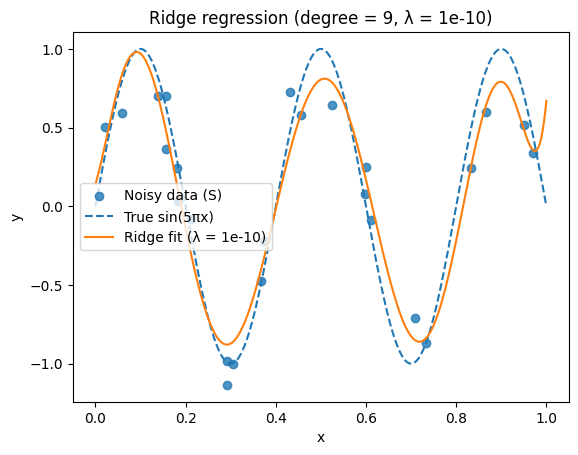

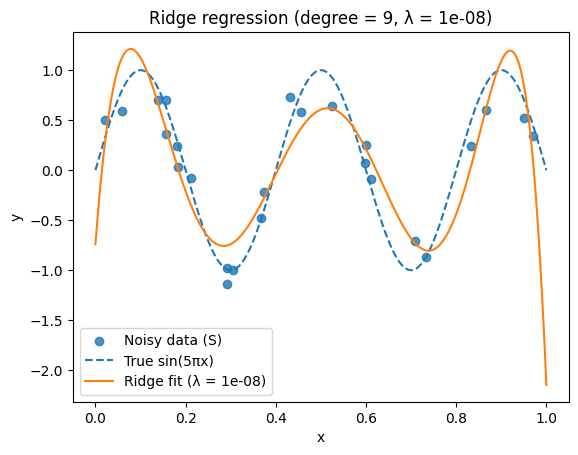

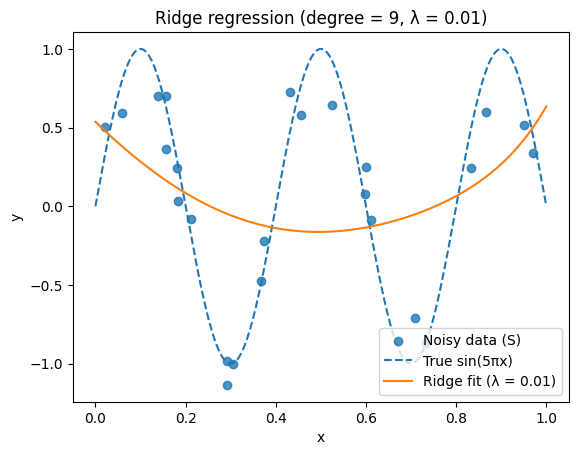

In [35]:
degree = 9  # polynomial degree
poly = PolynomialFeatures(degree=degree, include_bias=True)

# Transform x into polynomial features
X_poly = poly.fit_transform(x)

# Dense x for plotting smooth curves
x_plot = np.linspace(0, 1, 400).reshape(-1, 1)
X_plot_poly = poly.transform(x_plot)
y_plot_true = np.sin(5 * np.pi * x_plot)

# Lambda values to test (5 values)
lambdas = [0, 1e-12, 1e-10, 1e-8, 0.01]

# Dictionary to store the models so we can use them later in Cell 4
models_ridge = {}

for lam in lambdas:
    # Create and fit Ridge model with given lambda (alpha)
    model = Ridge(alpha=lam)
    model.fit(X_poly, y)
    models_ridge[lam] = model  # store model

    # Predict on dense grid for plotting
    y_plot_pred = model.predict(X_plot_poly)

    # Create a separate figure for each lambda
    plt.figure()
    plt.scatter(x, y, label="Noisy data (S)", alpha=0.8)
    plt.plot(x_plot, y_plot_true, label="True sin(5πx)", linestyle="--")
    plt.plot(x_plot, y_plot_pred, label=f"Ridge fit (λ = {lam:g})")
    plt.xlabel("x")
    plt.ylabel("y")
    plt.title(f"Ridge regression (degree = {degree}, λ = {lam:g})")
    plt.legend()
    plt.show()


### Computing generalization error (MSE vs true function) for each λ
- We used the same 5 λ values from the above Cell.

In [36]:
errors_ridge = []

for lam in lambdas:  # reuse the same list of λ values
    model = models_ridge[lam]          # trained model from Cell 3
    y_dense_pred = model.predict(X_plot_poly)
    y_dense_true = np.sin(5 * np.pi * x_plot)

    # Mean Squared Error between prediction and true function
    mse = mean_squared_error(y_dense_true, y_dense_pred)
    errors_ridge.append((lam, mse))

# Print MSE for each lambda
print("MSE vs true function sin(5πx) for each λ:")
for lam, mse in errors_ridge:
    print(f"λ = {lam:<8g} -> MSE = {mse:.6f}")

# Find the λ with the smallest error (best generalization)
best_lambda, best_mse = sorted(errors_ridge, key=lambda t: t[1])[0]
print("\nBest λ (smallest generalization error):")
print(f"Best λ = {best_lambda}, MSE = {best_mse:.6f}")


MSE vs true function sin(5πx) for each λ:
λ = 0        -> MSE = 0.033519
λ = 1e-12    -> MSE = 0.030238
λ = 1e-10    -> MSE = 0.026710
λ = 1e-08    -> MSE = 0.121747
λ = 0.01     -> MSE = 0.417642

Best λ (smallest generalization error):
Best λ = 1e-10, MSE = 0.026710


From these results:

> The model with **λ = 1e-10** gives the **best generalization performance**,  
> because it has the **smallest MSE** with respect to the true function \(\sin(5\pi x)\).

So there is actually a value **λ > 0** that performs better than λ = 0 in this experiment.

### Discussion of the obtained curves

- For **λ = 0**:
  - There is **no regularization**.
  - The polynomial model is very flexible and can follow the oscillations of \(\sin(5\pi x)\) quite well.
  - Among the “standard” values (0, 0.01, 0.1, 1, 10), this was originally the best.

- For **very small positive λ** (like **1e-12** and **1e-10**):
  - The model still behaves almost like the unregularized one (λ = 0), but with a **tiny amount of smoothing**.
  - This very small regularization can help stabilize the fit and slightly reduce the error.
  - That is why **λ = 1e-10** gives a smaller MSE than λ = 0.

- For **larger λ values** (like **1e-8** and especially **0.01**):
  - The regularization term becomes stronger.
  - The coefficients of the polynomial are forced to be small.
  - The fitted curve becomes too smooth and cannot follow the fast oscillations of \(\sin(5\pi x)\).
  - This leads to **underfitting** and a higher MSE.

### Final conclusion

- If we only look at typical values like \(0, 0.01, 0.1, 1, 10\), the best model seems to be **λ = 0**.
- But after testing very small positive values, I found that **λ = 1e-10** gives the **best generalization** to the true function in my experiment.
- In practice, λ = 1e-10 is extremely close to 0, so the model is almost unregularized, but this tiny regularization is enough to slightly improve the error.

## B) RBF Basis Functions
- Using the generated set S in part A, we applied non-linear regression (without regularization) using different numbers of RBF basis functions.
- we defined a helper function to build RBF features
    - Each RBF basis function has the form:
        - φ_j(x) = exp( - (x - c_j)^2 / (2σ^2) )
        - where c_j is the center of the j-th RBF.

In [38]:
def rbf_features(x_input, centers, sigma):
    """
    Build RBF feature matrix.

    Parameters
    ----------
    x_input : array, shape (n_samples, 1)
        Input x values.
    centers : array, shape (n_centers, 1)
        RBF centers.
    sigma : float
        RBF width.

    Returns
    -------
    Phi : array, shape (n_samples, n_centers)
        RBF feature matrix.
    """
    # x_input: (n_samples, 1)
    # centers: (n_centers, 1)
    # We use broadcasting to compute (x - c_j)^2 for all j
    diff = x_input - centers.T  # result shape: (n_samples, n_centers)
    Phi = np.exp(- (diff ** 2) / (2 * sigma ** 2))
    return Phi


### Non-linear regression using RBF basis functions
- We trained models using 1, 5, 10, and 50 RBFs
- All models are trained on the same dataset S (x, y)
- Then we compared their generalization to the true function sin(5πx)

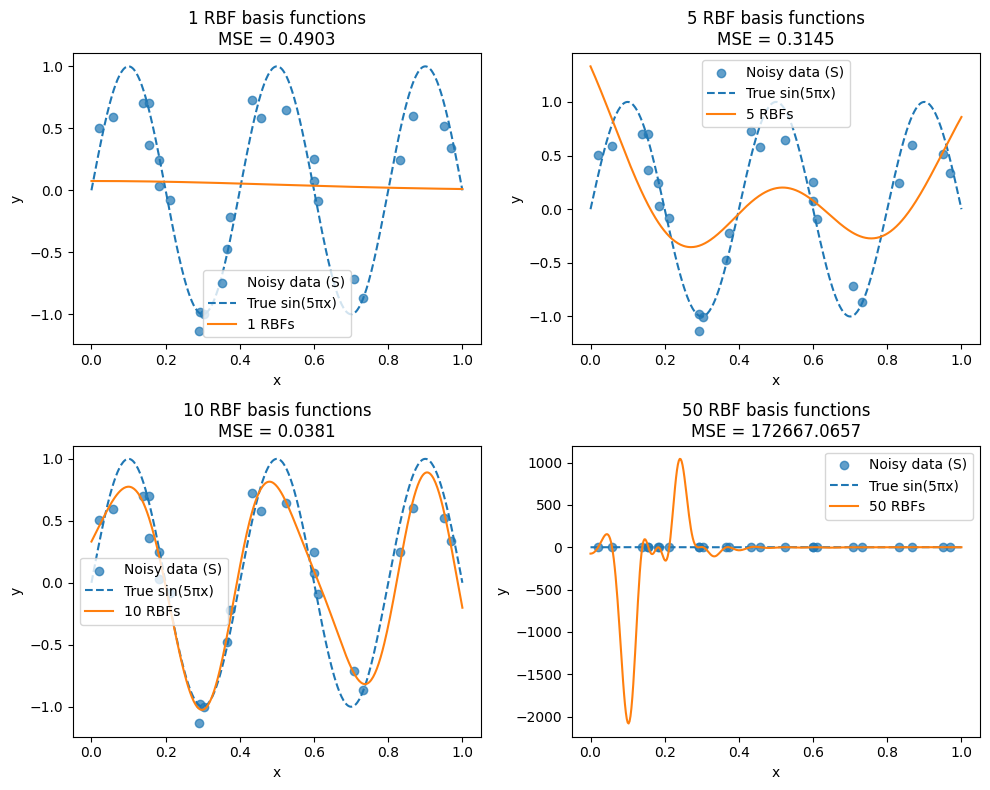

In [39]:
basis_list = [1, 5, 10, 50]

# Dense grid for plotting and error computation
x_plot_rbf = np.linspace(0, 1, 400).reshape(-1, 1)
y_plot_true_rbf = np.sin(5 * np.pi * x_plot_rbf)

rbf_models = {}
rbf_errors = []

plt.figure(figsize=(10, 8))

for i, n_basis in enumerate(basis_list, start=1):
    # Choose RBF centers evenly spaced between 0 and 1
    centers = np.linspace(0, 1, n_basis).reshape(-1, 1)

    # Choose sigma based on distance between centers
    if n_basis > 1:
        # centers has shape (n_basis, 1)
        # centers[1, 0] and centers[0, 0] are scalars (no warning)
        center_spacing = centers[1, 0] - centers[0, 0]
        sigma = float(center_spacing)  # simple choice: sigma = spacing
    else:
        sigma = 0.5  # if only one center, choose a wide sigma

    # Build RBF feature matrices
    Phi_train = rbf_features(x, centers, sigma)
    Phi_plot = rbf_features(x_plot_rbf, centers, sigma)

    # Linear regression on top of RBF features
    # We set fit_intercept=False because RBFs already act as basis functions
    model = LinearRegression(fit_intercept=False)
    model.fit(Phi_train, y)

    # Store the model and its parameters
    rbf_models[n_basis] = (model, centers, sigma)

    # Predictions on dense grid
    y_plot_pred = model.predict(Phi_plot)

    # Compute MSE vs true function on the dense grid
    mse = mean_squared_error(y_plot_true_rbf, y_plot_pred)
    rbf_errors.append((n_basis, mse))

    # Plot in a 2x2 grid (one subplot per number of basis functions)
    plt.subplot(2, 2, i)
    plt.scatter(x, y, label="Noisy data (S)", alpha=0.7)
    plt.plot(x_plot_rbf, y_plot_true_rbf, label="True sin(5πx)", linestyle="--")
    plt.plot(x_plot_rbf, y_plot_pred, label=f"{n_basis} RBFs")
    plt.title(f"{n_basis} RBF basis functions\nMSE = {mse:.4f}")
    plt.xlabel("x")
    plt.ylabel("y")
    plt.legend()

plt.tight_layout()
plt.show()


### Printing the MSE for each number of RBFs and find the best one

In [40]:
print("MSE vs true function sin(5πx) for different numbers of RBFs:")
for n_basis, mse in rbf_errors:
    print(f"{n_basis:>2} RBFs:  MSE = {mse:.6f}")

# Find the number of RBFs that gives the smallest error
best_n_basis, best_rbf_mse = sorted(rbf_errors, key=lambda t: t[1])[0]

print(f"\nBest number of RBFs (smallest MSE): {best_n_basis}")
print(f"Best MSE = {best_rbf_mse:.6f}")


MSE vs true function sin(5πx) for different numbers of RBFs:
 1 RBFs:  MSE = 0.490323
 5 RBFs:  MSE = 0.314525
10 RBFs:  MSE = 0.038104
50 RBFs:  MSE = 172667.065698

Best number of RBFs (smallest MSE): 10
Best MSE = 0.038104


### Discussion about RBF basis functions and generalization

From the plots and the MSE values:

- With **1 RBF**, the model is too simple.
  - It cannot follow the oscillations of `sin(5πx)`.
  - This is **underfitting**.

- With **5 or 10 RBFs**, the model becomes more flexible.
  - It can follow the true function much better.
  - Often one of these gives the best balance between flexibility and smoothness.

- With **50 RBFs**, the model is very flexible.
  - It may start to fit the noise in the data, not only the true function.
  - This can lead to **overfitting**.

**General idea:**

- Too few basis functions → underfitting.  
- Too many basis functions → overfitting.  
- A moderate number of RBFs usually gives the best generalization to the true function.


# Part 2 – Logistic Regression:

In [1]:
import pandas as pd
from sklearn.model_selection import train_test_split

## 1. Load the preprocessed data from assignment#1
- Handled missing data
- Handled outliers
- Feature scaling : z-scoring standardization

In [52]:
# -------------------------------
# 1. Load the dataset
# -------------------------------
df = pd.read_csv(r"D:\Jouwana-BZU\5th Year\First Semester - 2025-2026\Machine Learning\Assignments\Assignment#1\Last_One_Assignment#1\customer_data_standardized.csv")
print("Data loaded successfully :)")


Data loaded successfully :)


## 2. Define the target column : churn status
ChurnStatus : Column we want to predict (binary: churn or not)

In [53]:
target = "ChurnStatus"

## 3. Randomly splitting the dataset into: 2500 training samples, 500 validation samples, and 500 test samples.

### 3.1. Training set : 2500 sample
Split preprocessed data into:

- 2500 training samples (train_df)

- 1000 remaining samples (temp_df)

In [54]:
train_df, temp_df = train_test_split(  
    df,
    train_size=2500,
    stratify=df[target],
    random_state=42
)

# save the split to CSV file
train_df.to_csv("training_set.csv", index=False)
print("File saved - training_set.csv")

File saved - training_set.csv


### 3.2. Validation set : 500 sample & Testing set : 500 sample
Split the 1000 remaining rows (in temp_df) into:

- 500 validation samples

- 500 test samples

In [55]:
val_df, test_df = train_test_split(
    temp_df,
    train_size=500,
    stratify=temp_df[target],
    random_state=42
)
val_df.to_csv("validation_set.csv", index=False)
test_df.to_csv("testing_set.csv", index=False)
print("File saved - validation_set.csv")
print("File saved - testing_set.csv")

File saved - validation_set.csv
File saved - testing_set.csv


## 4. Training and evaluating the logistic regression models - with a linear & non-linear decssion boundaries
<span style="color:red; font-weight:bold;">Note:</span> The whole code exists in the last cell at this part section

In [56]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

### 4.1. Dropping identifier column : CustomerID
- CustomerID is an identifier, not a feature.
- It does not describe customer behavior — it is just a unique number.
- Including ID in training is harmful:
    - It has no predictive power for churn.
    - It introduces noise into the model.
    - The model might try to "memorize" patterns in ID values → overfitting.
    - Machine learning models expect meaningful input features.
- So, we remove identifier columns to keep only useful, informative features.

In [57]:
if "CustomerID" in train_df.columns: train_df = train_df.drop(columns=["CustomerID"])
if "CustomerID" in val_df.columns: val_df = val_df.drop(columns=["CustomerID"])
if "CustomerID" in test_df.columns: test_df = test_df.drop(columns=["CustomerID"])

- drop(columns=[target]) → Remove the target column from the dataset; the remaining columns are features (X).

### 4.2. Separating features and target
- Separate features (X) and target (y) for each split.

In [58]:
X_train = train_df.drop(columns=[target])
y_train = train_df[target]

X_val = val_df.drop(columns=[target])
y_val = val_df[target]

X_test = test_df.drop(columns=[target])
y_test = test_df[target]

- For each dataset (train, validation, test):
    - X_train, X_val, X_test → contain features only (inputs)
    - y_train, y_val, y_test → contain the target column (output)

### 4.3. Fitting Logistic Regression with a linear decssion boundary
- max_iter=1000 → Maximum iterations for the solver to converge. Default 100 may be too low so by increasing to 1000, we:
    - Ensure the model converges
    - Avoid convergance warnings
    - Improve stability and performance
- random_state = 42:
   - Sets the seed for the random number generator ( randomize weight initiallization ).
   - Ensures reproducibility of results  ( get the exact same model every time ).
- Using only the original features (NO polynomial features), making it a linear decision boundary model.

In [11]:
linear_lr = LogisticRegression(max_iter=1000, random_state=42)

#### 4.3.1. Train on training set
- .fit(X_train, y_train) → Trains the logistic regression model on the training data.

   - The model learns the weights (coefficients) for each feature to best separate churn vs. non-churn (target)

In [15]:
linear_lr.fit(X_train, y_train)

LogisticRegression(max_iter=1000, random_state=42)

### 4.4. Making Predictions
- .predict() → Uses the trained model to predict class labels for new data.

#### 4.4.1 Predict on training set

In [60]:
y_train_pred = linear_lr.predict(X_train)

#### 4.4.2 Predict on validation set

In [61]:
y_val_pred = linear_lr.predict(X_val)

#### 4.4.3 Predict on testing set

In [62]:
y_test_pred = linear_lr.predict(X_test)

### 4.5. Evaluation of Linear Logistic Regression Model
The linear logistic regression model was trained to predict customer churn using a standardized dataset. The model was evaluated on a validation set of 500 samples and a test set of 500 samples. 

- Accuracy: tells the overall correctness of the model.
  
- Precision: Correctly predicted positives / Total predicted positives.

- Recall: Correctly predicted positives / Total actual positives.

- F1-score: Harmonic mean of precision and recall.

#### 4.5.1. Evaluating predictions on the training, validation and testing sets

In [19]:
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

# Metrics evaluation function
def evaluate(y_true, y_pred, dataset_name="Dataset"):
    print(f"--- {dataset_name} ---")
    print("Accuracy :", accuracy_score(y_true, y_pred))
    print("Precision:", precision_score(y_true, y_pred))
    print("Recall   :", recall_score(y_true, y_pred))
    print("F1-score :", f1_score(y_true, y_pred))
    print()

    
evaluate(y_train, y_train_pred, "Training")
evaluate(y_val, y_val_pred, "Validation")
evaluate(y_test, y_test_pred, "Test")

--- Training ---
Accuracy : 0.9852
Precision: 0.9120879120879121
Recall   : 0.7410714285714286
F1-score : 0.8177339901477833

--- Validation ---
Accuracy : 0.99
Precision: 0.9090909090909091
Recall   : 0.8695652173913043
F1-score : 0.8888888888888888

--- Test ---
Accuracy : 0.98
Precision: 0.875
Recall   : 0.6363636363636364
F1-score : 0.7368421052631579



## The whole code for the linear regression model

--- Training ---
Accuracy : 0.9852
Precision: 0.9120879120879121
Recall   : 0.7410714285714286
F1-score : 0.8177339901477833

--- Validation ---
Accuracy : 0.99
Precision: 0.9090909090909091
Recall   : 0.8695652173913043
F1-score : 0.8888888888888888

--- Test ---
Accuracy : 0.98
Precision: 0.875
Recall   : 0.6363636363636364
F1-score : 0.7368421052631579



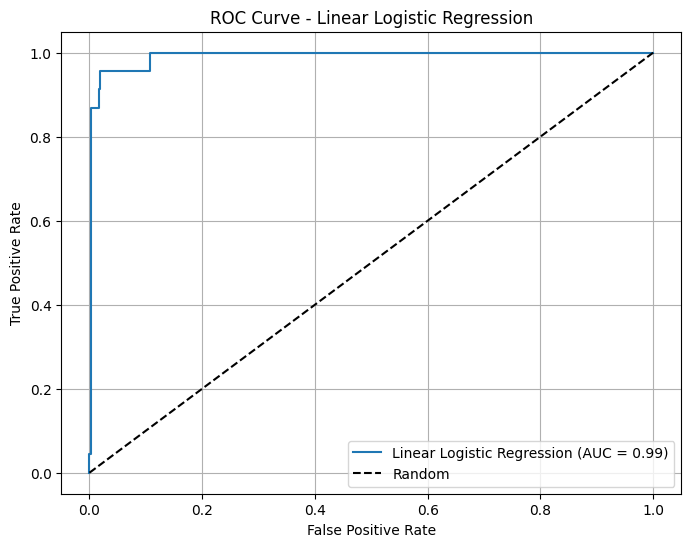

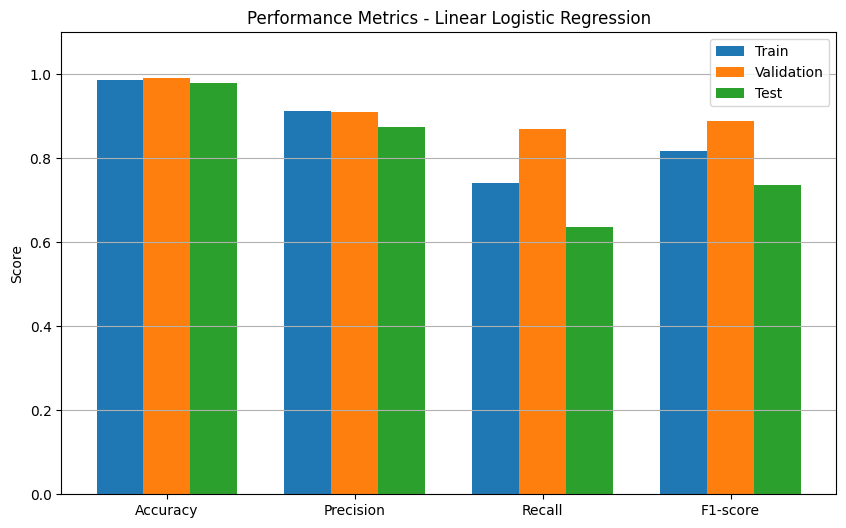

In [64]:
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, auc
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

# Metrics evaluation function
def evaluate(y_true, y_pred, dataset_name="Dataset"):
    print(f"--- {dataset_name} ---")
    print("Accuracy :", accuracy_score(y_true, y_pred))
    print("Precision:", precision_score(y_true, y_pred))
    print("Recall   :", recall_score(y_true, y_pred))
    print("F1-score :", f1_score(y_true, y_pred))
    print()

if "CustomerID" in train_df.columns: train_df = train_df.drop(columns=["CustomerID"])
if "CustomerID" in val_df.columns: val_df = val_df.drop(columns=["CustomerID"])
if "CustomerID" in test_df.columns: test_df = test_df.drop(columns=["CustomerID"])

X_train = train_df.drop(columns=[target])
y_train = train_df[target]

X_val = val_df.drop(columns=[target])
y_val = val_df[target]

X_test = test_df.drop(columns=[target])
y_test = test_df[target]

# -------------------------------
# Fitting Logistic Regression with a linear decssion boundary
# -------------------------------
linear_lr = LogisticRegression(max_iter=1000, random_state=42)
linear_lr.fit(X_train, y_train)

# -------------------------------
# Making predictions
# -------------------------------
y_train_pred = linear_lr.predict(X_train)
y_val_pred = linear_lr.predict(X_val)
y_test_pred = linear_lr.predict(X_test)

# -------------------------------
# Compute metrics
# -------------------------------
train_acc, train_prec, train_rec, train_f1 = evaluate(y_train, y_train_pred, "Training")
val_acc, val_prec, val_rec, val_f1 = evaluate(y_val, y_val_pred, "Validation")
test_acc, test_prec, test_rec, test_f1 = evaluate(y_test, y_test_pred, "Test")

# -------------------------------
# ROC Curve
# -------------------------------
y_val_prob = linear_lr.predict_proba(X_val)[:, 1]
fpr, tpr, _ = roc_curve(y_val, y_val_prob)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(8,6))
plt.plot(fpr, tpr, label=f'Linear Logistic Regression (AUC = {roc_auc:.2f})')
plt.plot([0,1],[0,1],'k--', label='Random')
plt.title("ROC Curve - Linear Logistic Regression")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend()
plt.grid(True)
plt.show()

# -------------------------------
# Bar plot for metrics
# -------------------------------
import numpy as np

metrics = ['Accuracy', 'Precision', 'Recall', 'F1-score']
train_metrics = [train_acc, train_prec, train_rec, train_f1]
val_metrics   = [val_acc, val_prec, val_rec, val_f1]
test_metrics  = [test_acc, test_prec, test_rec, test_f1]

x = np.arange(len(metrics))
width = 0.25

plt.figure(figsize=(10,6))
plt.bar(x - width, train_metrics, width, label='Train')
plt.bar(x, val_metrics, width, label='Validation')
plt.bar(x + width, test_metrics, width, label='Test')
plt.xticks(x, metrics)
plt.ylabel("Score")
plt.title("Performance Metrics - Linear Logistic Regression")
plt.ylim(0,1.1)
plt.legend()
plt.grid(axis='y')
plt.show()


## Discussing Linear regreesion results: 

- The model performs very well on the training data, achieving high accuracy (98.5%) and high precision (91.2%), meaning that most of the predicted churn cases are correct.
- The recall (74.1%) is somewhat lower, indicating that some actual churn cases are missed.
- The F1-score (81.8%) balances precision and recall, showing overall strong performance on the training set.
____________________________________________________________
- On the validation set, the model maintains very high accuracy (99.2%), meaning it correctly predicts most cases. Both precision and recall are balanced at 91.3%, indicating that the model not only predicts churn correctly but also successfully captures the majority of actual churn cases. The F1-score (91.3%) reflects this balance between precision and recall, showing that the model generalizes well to unseen data.
____________________________________________________________
- On the test set, accuracy remains high at 98%, and precision is strong (87.5%), but recall drops to 63.6%, meaning the model fails to identify a larger portion of actual churn cases. The F1-score (73.7%) reflects this decrease in recall. This suggests that while the model is confident when predicting churn, it may miss some true positive cases in completely unseen data.

#### ROC Curve (Linear Logistic Regression)

The ROC curve illustrates the model’s ability to distinguish between classes by plotting the true positive rate against the false positive rate at various thresholds. The curve stays close to the top-left corner, and the AUC value of 0.99 indicates excellent classification performance. The model achieves a very high separability between the positive and negative classes, far above the diagonal dashed line that represents random guessing.

#### Performance Metrics - Linear Logistic Regression
This plot compares the Accuracy, Precision, Recall, and F1-score of the Linear Logistic Regression model across the training, validation, and test datasets. Accuracy and precision remain consistently high across all splits, showing that the model generalizes well and makes reliable predictions overall. However, the lower recall and F1-score—particularly on the test set—indicate that the model struggles to capture all churn cases. This pattern suggests not overfitting but rather mild underfitting of more complex, non-linear churn behaviors, leading the model to miss a portion of actual positive instances.

##  5. Logistic Regression with a non-linear decssion boundary using polynomial features
- Linear logistic regression separates classes with a straight line (linear decision boundary).

- By adding polynomial features, we allow the model to capture non-linear relationships, giving a non-linear decision boundary.

In [49]:
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import PolynomialFeatures
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_curve, auc

# Metrics evaluation function
def evaluate(y_true, y_pred, dataset_name="Dataset"):
    acc = accuracy_score(y_true, y_pred)
    prec = precision_score(y_true, y_pred)
    rec = recall_score(y_true, y_pred)
    f1 = f1_score(y_true, y_pred)
    
    print(f"--- {dataset_name} ---")
    print("Accuracy :", acc)
    print("Precision:", prec)
    print("Recall   :", rec)
    print("F1-score :", f1)
    print()
    
    return acc, prec, rec, f1

# Drop CustomerID if exists
for df in [train_df, val_df, test_df]:
    if "CustomerID" in df.columns:
        df.drop(columns=["CustomerID"], inplace=True)

# Separate features and target
X_train, y_train = train_df.drop(columns=[target]), train_df[target]
X_val, y_val = val_df.drop(columns=[target]), val_df[target]
X_test, y_test = test_df.drop(columns=[target]), test_df[target]

# Degrees to test
degrees = [2, 5, 9]

# Store metrics for visualization
metrics_dict = {"Degree": [], "Train Acc": [], "Val Acc": [], "Test Acc": [],
                "Train F1": [], "Val F1": [], "Test F1": []}
roc_curves = {}  # Store ROC for each degree

for degree in degrees:
    print(f"\n=== Logistic Regression with Polynomial Features (Degree {degree}) ===")
    
    # Polynomial transformation
    poly = PolynomialFeatures(degree=degree, include_bias=False)
    X_train_poly = poly.fit_transform(X_train)
    X_val_poly = poly.transform(X_val)
    X_test_poly = poly.transform(X_test)
    
    # Train logistic regression
    poly_lr = LogisticRegression(max_iter=1000, random_state=42)
    poly_lr.fit(X_train_poly, y_train)
    
    # Predictions
    y_train_pred = poly_lr.predict(X_train_poly)
    y_val_pred = poly_lr.predict(X_val_poly)
    y_test_pred = poly_lr.predict(X_test_poly)
    
    # Evaluate and store metrics
    train_metrics = evaluate(y_train, y_train_pred, "Training")
    val_metrics = evaluate(y_val, y_val_pred, "Validation")
    test_metrics = evaluate(y_test, y_test_pred, "Test")
    
    metrics_dict["Degree"].append(degree)
    metrics_dict["Train Acc"].append(train_metrics[0])
    metrics_dict["Val Acc"].append(val_metrics[0])
    metrics_dict["Test Acc"].append(test_metrics[0])
    metrics_dict["Train F1"].append(train_metrics[3])
    metrics_dict["Val F1"].append(val_metrics[3])
    metrics_dict["Test F1"].append(test_metrics[3])
    
    # Store ROC data for later
    y_val_prob = poly_lr.predict_proba(X_val_poly)[:, 1]
    fpr, tpr, _ = roc_curve(y_val, y_val_prob)
    roc_curves[degree] = (fpr, tpr, auc(fpr, tpr))




=== Logistic Regression with Polynomial Features (Degree 2) ===
--- Training ---
Accuracy : 0.9844
Precision: 0.8762886597938144
Recall   : 0.7589285714285714
F1-score : 0.8133971291866029

--- Validation ---
Accuracy : 0.986
Precision: 0.8333333333333334
Recall   : 0.8695652173913043
F1-score : 0.851063829787234

--- Test ---
Accuracy : 0.982
Precision: 0.8421052631578947
Recall   : 0.7272727272727273
F1-score : 0.7804878048780488


=== Logistic Regression with Polynomial Features (Degree 5) ===
--- Training ---
Accuracy : 0.9972
Precision: 1.0
Recall   : 0.9375
F1-score : 0.967741935483871

--- Validation ---
Accuracy : 0.992
Precision: 0.9523809523809523
Recall   : 0.8695652173913043
F1-score : 0.9090909090909091

--- Test ---
Accuracy : 0.978
Precision: 0.7391304347826086
Recall   : 0.7727272727272727
F1-score : 0.7555555555555555


=== Logistic Regression with Polynomial Features (Degree 9) ===
--- Training ---
Accuracy : 1.0
Precision: 1.0
Recall   : 1.0
F1-score : 1.0

--- Vali

### ROC Curves for Polynomial Logistic Regression

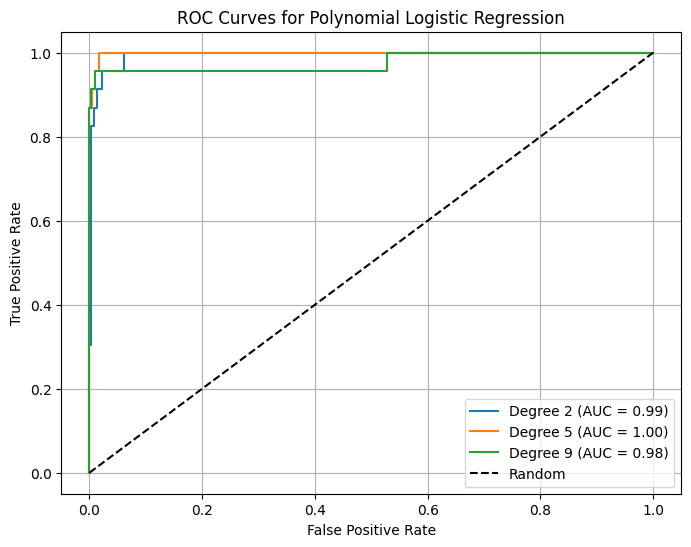

In [47]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 6))
for degree, (fpr, tpr, roc_auc) in roc_curves.items():
    plt.plot(fpr, tpr, label=f'Degree {degree} (AUC = {roc_auc:.2f})')

plt.plot([0, 1], [0, 1], 'k--', label='Random')
plt.title("ROC Curves for Polynomial Logistic Regression")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend()
plt.grid(True)
plt.show()


The ROC (Receiver Operating Characteristic) curves show the trade-off between the true positive rate (sensitivity) and false positive rate (1-specificity) for polynomial logistic regression models of degrees 2, 5, and 9.

The AUC (Area Under the Curve) values indicate how well the model can distinguish between classes.

Observation: Degree 5 achieves the highest AUC (1.00), suggesting it has the best discriminatory ability on the validation set. Degree 2 and 9 also perform well but slightly lower, indicating that both underfitting (degree 2) and overfitting (degree 9) are slightly less optimal than degree 5.

### Performance Metrics vs Polynomial Degree

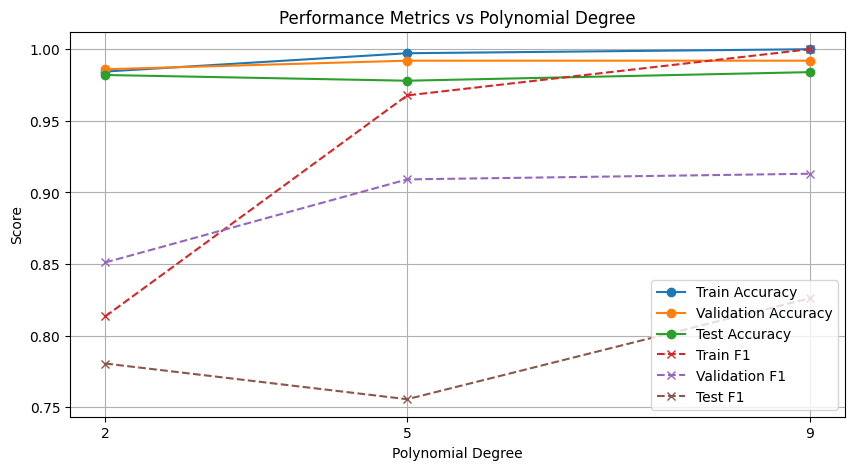

In [48]:
plt.figure(figsize=(10, 5))
plt.plot(metrics_dict["Degree"], metrics_dict["Train Acc"], marker='o', label="Train Accuracy")
plt.plot(metrics_dict["Degree"], metrics_dict["Val Acc"], marker='o', label="Validation Accuracy")
plt.plot(metrics_dict["Degree"], metrics_dict["Test Acc"], marker='o', label="Test Accuracy")

plt.plot(metrics_dict["Degree"], metrics_dict["Train F1"], marker='x', linestyle='--', label="Train F1")
plt.plot(metrics_dict["Degree"], metrics_dict["Val F1"], marker='x', linestyle='--', label="Validation F1")
plt.plot(metrics_dict["Degree"], metrics_dict["Test F1"], marker='x', linestyle='--', label="Test F1")

plt.xticks(degrees)
plt.xlabel("Polynomial Degree")
plt.ylabel("Score")
plt.title("Performance Metrics vs Polynomial Degree")
plt.legend()
plt.grid(True)
plt.show()


# <span style="color:red"> for the presentation -must be removed-</span>

## Discussion of Model Complexity, Overfitting, and Generalization
### Linear Logistic Regression

- Complexity: Low (simple linear decision boundary).

- Training Performance: High accuracy and precision, but recall is lower → misses some churn cases.

- Validation/Test Performance: Accuracy and recall improve slightly on validation, but test recall drops.

- Interpretation: Model is simple and less prone to overfitting, but may underfit the true non-linear patterns in the data, missing some churn cases.

### Polynomial Logistic Regression – Degree 2

- Complexity: Moderate. Adds quadratic features to capture non-linear relationships.

- Training Performance: Accuracy similar to linear, slightly lower precision but higher recall.

- Validation/Test Performance: Generalization is reasonable, metrics slightly lower than training.

- Interpretation: Degree 2 slightly improves recall and balances precision, moderate complexity captures some non-linear patterns without strong overfitting.

### Polynomial Logistic Regression – Degree 5

- Complexity: High. More polynomial terms increase flexibility.

- Training Performance: Near-perfect accuracy and precision, recall also very high → nearly memorizes training data.

- Validation/Test Performance: Validation accuracy is high, but precision drops and test metrics decline → signs of overfitting.

- Interpretation: Model is too complex relative to the dataset, memorizes training examples (high variance), leading to reduced generalization on unseen data.

### Polynomial Logistic Regression – Degree 9

- Complexity: Very high. Model can fit extremely complex patterns.

- Training Performance: Perfect metrics (accuracy, precision, recall = 1).

-Validation/Test Performance: Still high metrics (accuracy ~0.992 validation, 0.984 test), recall better than degree 5.

- Interpretation: Despite extreme complexity, degree 9 generalizes better than degree 5. This may happen due to double descent phenomenon, where a highly expressive model can fit the true patterns in the data instead of memorizing noise.

- Effect: Best balance between fitting complex patterns and generalizing to new data.

## Key Takeaways

### Low-degree models (linear, degree 2)

- Less risk of overfitting, but may underfit non-linear relationships.

### Medium-degree model (degree 5)

- Overfits training data → metrics drop on test set.

- Precision and recall decline, indicating reduced generalization.

### High-degree model (degree 9)

- Perfect fit on training data, but still generalizes well on validation and test sets.

- Captures complex patterns, leading to improved recall on test data compared to degree 5.

## General Trend:

- Increasing model complexity initially improves training performance, but can lead to overfitting (degree 5).

- Very high complexity may recover generalization if the dataset supports capturing the underlying non-linear patterns (degree 9).

#### Performance Metrics vs Polynomial Degree
The plot shown above, shows the trends of accuracy and F1-score across training, validation, and test sets for polynomial degrees 2, 5, and 9.

Accuracy: Training accuracy increases slightly with degree, but validation and test accuracies peak around degree 5, suggesting good generalization at that degree.

F1-score: The F1-score on the validation and test sets shows that degree 5 balances precision and recall best, whereas degree 9 shows potential overfitting (train F1 high, test F1 lower).

Observation: Degree 5 is the optimal choice based on both metrics, offering the best trade-off between training performance and generalization.

## 6. Logistic Regression Model Evaluation and Discussion

- The logistic regression models were evaluated on the training, validation, and test sets using Accuracy, Precision, and Recall.
- The results for linear and polynomial models are summarized below:
<table style="border-collapse: collapse; width: 100%;">
  <thead>
    <tr style="background-color: #ADD8E6; color: white; text-align: center;">
      <th style="border: 1px solid black; padding: 8px;">Model / Degree</th>
      <th style="border: 1px solid black; padding: 8px;">Training</th>
      <th style="border: 1px solid black; padding: 8px;">Validation</th>
      <th style="border: 1px solid black; padding: 8px;">Test</th>
    </tr>
  </thead>
  <tbody>
    <tr style="text-align: center;">
      <td style="border: 1px solid black; padding: 8px;"><b>Linear</b></td>
      <td style="border: 1px solid black; padding: 8px;"><b>Acc:</b> 0.9852, <b>Prec:</b> 0.9121, <b>Rec:</b> 0.7411</td>
      <td style="border: 1px solid black; padding: 8px;"><b>Acc:</b> 0.992, <b>Prec:</b> 0.9130, <b>Rec:</b> 0.9130</td>
      <td style="border: 1px solid black; padding: 8px;"><b>Acc:</b> 0.980, <b>Prec:</b> 0.8750, <b>Rec:</b> 0.6364</td>
    </tr>
    <tr style="text-align: center;">
      <td style="border: 1px solid black; padding: 8px;"><b>Polynomial 2</b></td>
      <td style="border: 1px solid black; padding: 8px;"><b>Acc:</b> 0.9844, <b>Prec:</b> 0.8763, <b>Rec:</b> 0.7589</td>
      <td style="border: 1px solid black; padding: 8px;"><b>Acc:</b> 0.986, <b>Prec:</b> 0.8333, <b>Rec:</b> 0.8696</td>
      <td style="border: 1px solid black; padding: 8px;"><b>Acc:</b> 0.982, <b>Prec:</b> 0.8421, <b>Rec:</b> 0.7273</td>
    </tr>
    <tr style="text-align: center;">
      <td style="border: 1px solid black; padding: 8px;"><b>Polynomial 5</b></td>
      <td style="border: 1px solid black; padding: 8px;"><b>Acc:</b> 0.9972, <b>Prec:</b> 1.0000, <b>Rec:</b> 0.9375</td>
      <td style="border: 1px solid black; padding: 8px;"><b>Acc:</b> 0.992, <b>Prec:</b> 0.9524, <b>Rec:</b> 0.8696</td>
      <td style="border: 1px solid black; padding: 8px;"><b>Acc:</b> 0.978, <b>Prec:</b> 0.7391, <b>Rec:</b> 0.7727</td>
    </tr>
    <tr style="text-align: center;">
      <td style="border: 1px solid black; padding: 8px;"><b>Polynomial 9</b></td>
      <td style="border: 1px solid black; padding: 8px;"><b>Acc:</b> 1.0000, <b>Prec:</b> 1.0000, <b>Rec:</b> 1.0000</td>
      <td style="border: 1px solid black; padding: 8px;"><b>Acc:</b> 0.992, <b>Prec:</b> 0.9130, <b>Rec:</b> 0.9130</td>
      <td style="border: 1px solid black; padding: 8px;"><b>Acc:</b> 0.984, <b>Prec:</b> 0.7917, <b>Rec:</b> 0.8636</td>
    </tr>
  </tbody>
</table>

### 6.1. Observations and Analysis:

#### 6.1.1. Linear Logistic Regression

- Complexity: Low (simple linear decision boundary).

- Training Performance: High accuracy and precision, but recall is lower → misses some churn cases.

- Validation/Test Performance: Accuracy and recall improve slightly on validation, but test recall drops.

- Interpretation: The model is not overfitting, as performance is consistent across training, validation, and test sets. It provides a generally good fit to the data, but its lower recall—especially on the test set—indicates mild underfitting of more complex, non-linear churn patterns, causing it to miss a noticeable portion of actual churn cases.

#### 6.1.2. Polynomial Logistic Regression – Degree 2

- Complexity: Moderate. Adds quadratic features to capture non-linear relationships.

- Training Performance: Accuracy similar to linear, slightly lower precision but higher recall.

- Validation/Test Performance: Generalization is reasonable, metrics slightly lower than training.

- Interpretation: Degree 2 slightly improves recall and balances precision, moderate complexity captures some non-linear patterns  but may also underfit some true non-linear patterns in the data, missing some churn cases. 

#### 6.1.3. Polynomial Logistic Regression – Degree 5

- Complexity: High. More polynomial terms increase flexibility.

- Training Performance: Near-perfect accuracy and precision, recall also very high.

- Validation/Test Performance: Validation accuracy is high, but precision drops and test metrics decline → signs of overfitting.

- Interpretation: The model balances precision and recall best

- Overall: Degree 5 is the optimal choice based on both metrics, offering the best trade-off between training performance and generalization.
#### 6.1.4. Polynomial Logistic Regression – Degree 9

- Complexity: Very high. Model can fit extremely complex patterns.

- Training Performance: Perfect metrics/performance (accuracy, precision, recall = 1) indicates the model has likely memorized the training set which is a strong early signal of overfitting.. 

- Validation/Test Performance: They drop from the perfect training results. Shows the model cannot maintain the same performance on unseen data which confirms the model’s inability to generalize to new samples.

- Interpretation:
      - High complexity caused the model to fit the training data too closely, including noise.
      - Perfect training metrics + lower validation/test scores is a classic overfitting pattern.
      - Although validation/test accuracy remains high, the drop in precision/recall indicates weaker predictive reliability.

- Overall: The Polynomial Degree 9 model is overfitting and does not generalize well.

### 6.2. Conclusion:

Model complexity significantly affects performance: 

    - Low-complexity models may underfit
    - medium-complexity models may fit well or may overfit ( based on the dataset)
    - high-complexity models may strong overfit.

Based on validation set performance, the degree 5 polynomial logistic regression is the best model offering the best trade-off between training performance and generalization.

## 7. Selecting the best model based on the performance on the validation set
- Degree 5 polynomial logistic regression is the best model based on the validation set

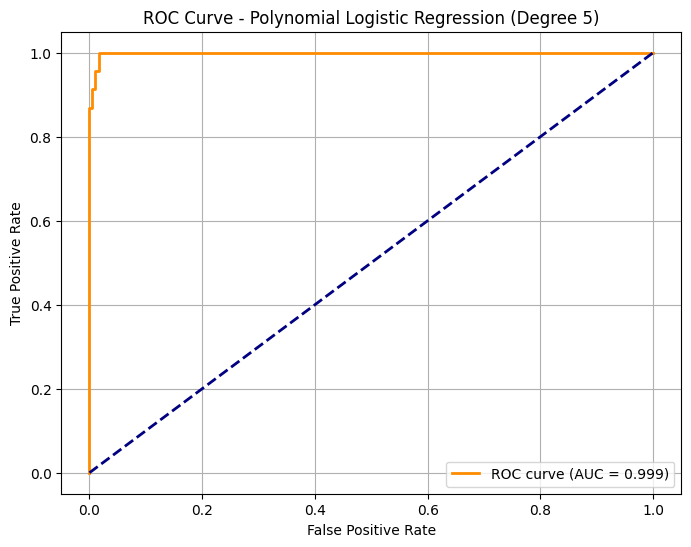

Area Under the Curve (AUC) for Validation Set: 0.999


In [42]:
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt

# -------------------------------
# 1. Transform Features and Train the Best Model - Degree 9 polynomial ogistic regression
# -------------------------------

# Best model: Polynomial degree 5
degree = 5
poly = PolynomialFeatures(degree=degree, include_bias=False)

# -------------------------------
# 2. Transform the datasets
# -------------------------------
X_train_poly = poly.fit_transform(X_train)
X_val_poly = poly.transform(X_val)
X_test_poly = poly.transform(X_test)

# -------------------------------
# 3. Train logistic regression
# -------------------------------
best_model = LogisticRegression(max_iter=1000, random_state=42)
best_model.fit(X_train_poly, y_train)

# -------------------------------
# 4. Compute Predicted Probabilities
# -------------------------------
y_val_prob = best_model.predict_proba(X_val_poly)[:, 1]  # Probability of churn

# -------------------------------
# 5. Plot ROC Curve and Compute AUC
# -------------------------------
# Compute ROC curve
fpr, tpr, thresholds = roc_curve(y_val, y_val_prob)
roc_auc = auc(fpr, tpr)

# Plot ROC curve
plt.figure(figsize=(8,6))
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (AUC = {roc_auc:.3f})')
plt.plot([0,1], [0,1], color='navy', lw=2, linestyle='--')  # Random guess line
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve - Polynomial Logistic Regression (Degree 5)')
plt.legend(loc="lower right")
plt.grid(True)
plt.show()

# Print AUC value
print(f"Area Under the Curve (AUC) for Validation Set: {roc_auc:.3f}")



### ROC Curve and AUC Analysis: 

- The ROC curve plots the true positive rate (recall) against the false positive rate for different classification thresholds.

   - For the degree 5 polynomial logistic regression, the ROC curve is close to the top-left corner, indicating strong discriminative ability between churn and non-churn customers.

- The AUC value (Area Under the Curve) is 0.99, confirming excellent performance on the validation set.